# Online Retailer Business Problem

## Objective
To analyze the online retail data to uncover insights about customer behavior and purchasing patterns. The goal is to identify trends and opportunities for business growth.


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Dataset Overview
The dataset contains transactions from an online retailer based in the UK, including details such as invoice number, stock code, description, quantity, invoice date, price, customer ID, and country.


In [18]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style='whitegrid')


In [19]:
# Load the dataset

file_path = "/content/drive/MyDrive/online_retail.csv"   # Change path if needed

df = pd.read_csv(file_path, encoding='ISO-8859-1')

# Display first 5 rows
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01-12-2009 07:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01-12-2009 07:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01-12-2009 07:45,1.25,13085.0,United Kingdom


## Data Cleaning
- Remove missing values
- Filter out canceled transactions
- Convert types if necessary


In [20]:
# Remove missing values
df.dropna(inplace=True)

# Remove cancelled transactions
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Convert InvoiceDate
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    dayfirst=True,
    format='mixed'
)

# Keep only positive quantity and price
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Check dataset
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Exploratory Data Analysis (EDA)
Explore top-selling products, customer purchase behavior, and time-based trends.


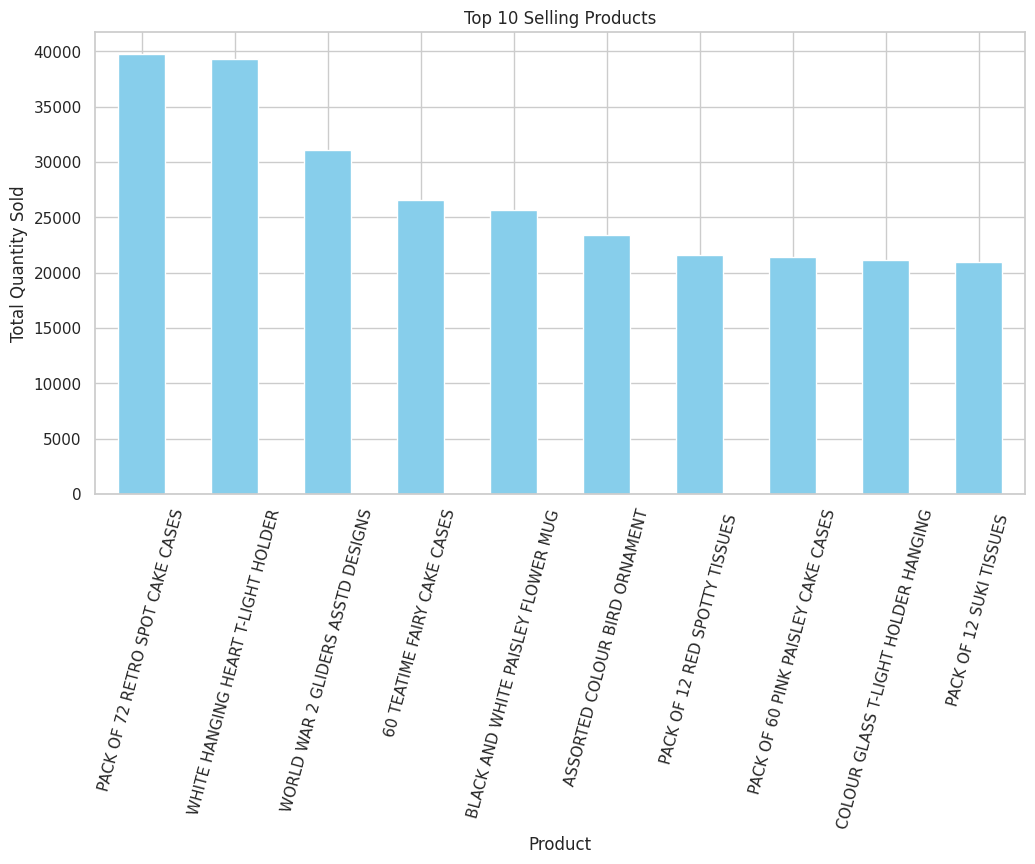

In [21]:
# Top 10 selling products

top_products = (
    df.groupby('Description')['Quantity']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
top_products.plot(kind='bar', color='skyblue')
plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=75)
plt.show()

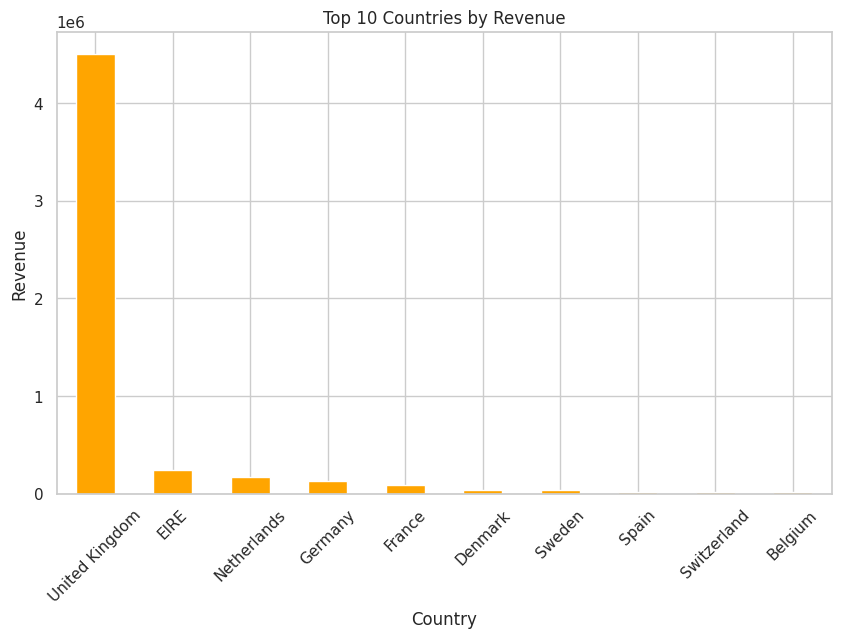

In [22]:
# Revenue per country
# Create Revenue column
df['Revenue'] = df['Quantity'] * df['Price']

country_revenue = (
    df.groupby('Country')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))
country_revenue.plot(kind='bar', color='orange')
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

## Customer Segmentation Preparation
Prepare RFM (Recency, Frequency, Monetary) analysis to understand customer segments.


In [23]:
# Snapshot date for recency calculation
# Create Revenue column if it doesn't exist
df['Revenue'] = df['Quantity'] * df['Price']

# Snapshot date (one day after the latest transaction)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Snapshot Date:", snapshot_date)
# RFM Table
# RFM Table
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Display first few rows
rfm.head()# RFM Table
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Display first few rows
rfm.head()

Snapshot Date: 2010-08-26 12:31:00


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,58,11,372.86
12349.0,100,2,1268.52
12355.0,97,1,488.21
12358.0,80,2,1697.93
12359.0,65,5,2012.03
